In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

In [3]:
raw = pd.read_csv("/content/rawdata.csv")

print("First 10 rows:")
print(raw.head(10))

print("\n.info():")
raw.info()

print("\n.describe():")
print(raw.describe())

First 10 rows:
   Duration        Date  Calories
0        60  2020-12-01     409.0
1        60  2020-12-02     479.0
2        60  2020-12-03     340.0
3        45  2020-12-04     282.0
4        45  2020-12-05     406.0
5        60  2020-12-06     436.0
6        60  2020-12-07     452.0
7        60  2020-12-08     352.0
8        45  2020-12-09     348.0
9        60         NaN     301.0

.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  61 non-null     int64  
 1   Date      59 non-null     object 
 2   Calories  59 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ KB

.describe():
         Duration    Calories
count   61.000000   59.000000
mean    64.426230  387.542373
std     50.448805   57.418705
min     45.000000  282.000000
25%     60.000000  348.000000
50%     60.000000  396.000000
75%     60.000000 

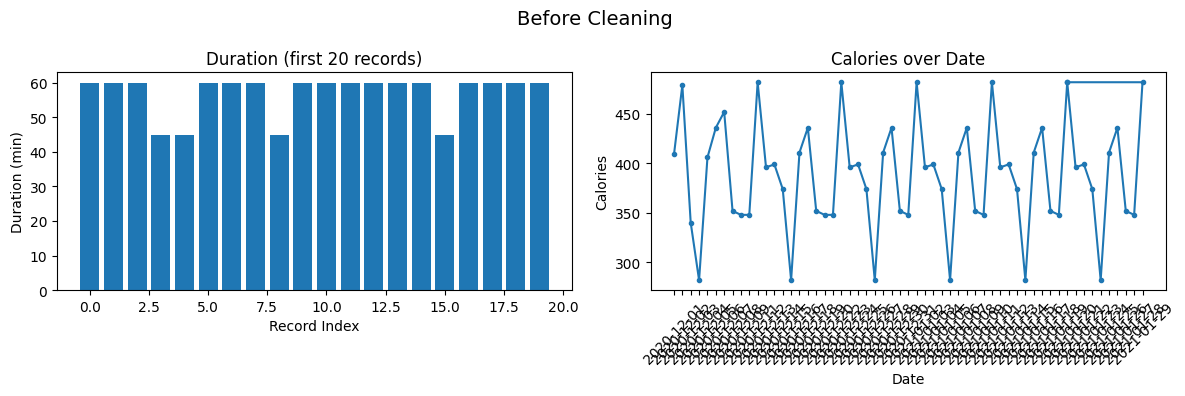

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Before Cleaning", fontsize=14)

axes[0].bar(range(20), raw["Duration"].head(20))
axes[0].set_title("Duration (first 20 records)")
axes[0].set_xlabel("Record Index")
axes[0].set_ylabel("Duration (min)")

temp = raw.dropna(subset=["Date", "Calories"])
axes[1].plot(temp["Date"], temp["Calories"], marker="o", markersize=3)
axes[1].set_title("Calories over Date")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Calories")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# Fill missing Calories with mean
raw["Calories"] = raw["Calories"].fillna(raw["Calories"].mean())

# Forward-fill missing Date values
raw["Date"] = raw["Date"].ffill()

# Convert Date to datetime
raw["Date"] = pd.to_datetime(raw["Date"])

# Replace Duration > 120 with median
median_duration = raw["Duration"].median()
raw["Duration"] = raw["Duration"].apply(
    lambda x: median_duration if x > 120 else x
)

# Remove duplicates
raw = raw.drop_duplicates().reset_index(drop=True)

print("Cleaned data (first 5 rows):")
print(raw.head())

Cleaned data (first 5 rows):
   Duration       Date  Calories
0      60.0 2020-12-01     409.0
1      60.0 2020-12-02     479.0
2      60.0 2020-12-03     340.0
3      45.0 2020-12-04     282.0
4      45.0 2020-12-05     406.0


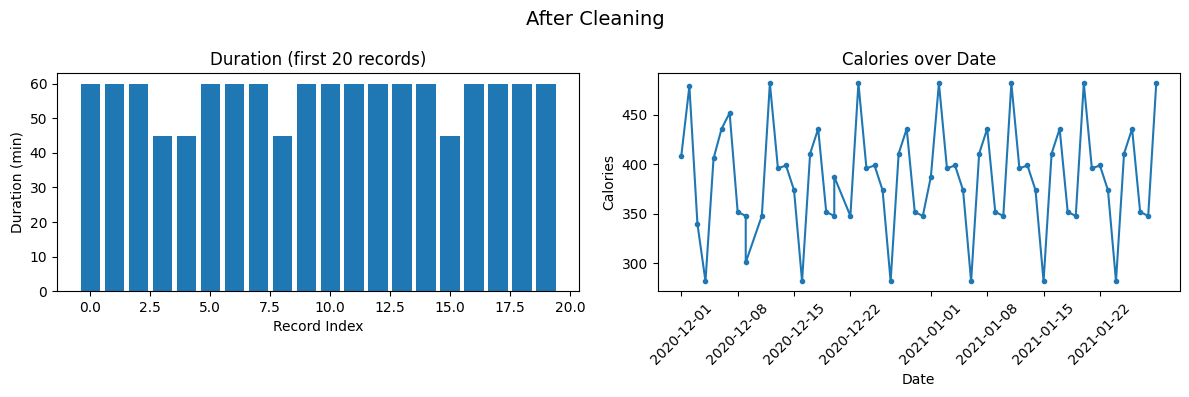

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("After Cleaning", fontsize=14)

axes[0].bar(range(min(20, len(raw))), raw["Duration"].head(20))
axes[0].set_title("Duration (first 20 records)")
axes[0].set_xlabel("Record Index")
axes[0].set_ylabel("Duration (min)")

axes[1].plot(raw["Date"], raw["Calories"], marker="o", markersize=3)
axes[1].set_title("Calories over Date")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Calories")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
import seaborn as sns

titanic = sns.load_dataset("titanic")

titanic = titanic.drop(
    columns=["alive", "alone", "embark_town", "who", "adult_male", "deck", "embarked", "class"]
)

print("Shape after dropping columns:", titanic.shape)
print(titanic.head())

Shape after dropping columns: (891, 7)
   survived  pclass     sex   age  sibsp  parch     fare
0         0       3    male  22.0      1      0   7.2500
1         1       1  female  38.0      1      0  71.2833
2         1       3  female  26.0      0      0   7.9250
3         1       1  female  35.0      1      0  53.1000
4         0       3    male  35.0      0      0   8.0500


In [8]:
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])

# Fill numerical missing with mean
num_cols = titanic.select_dtypes(include=[np.number]).columns
titanic[num_cols] = titanic[num_cols].fillna(titanic[num_cols].mean())

# Fill categorical missing with mode
cat_cols = titanic.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    titanic[col] = titanic[col].fillna(titanic[col].mode()[0])

print("Missing values after cleaning:")
print(titanic.isnull().sum())

Missing values after cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
dtype: int64


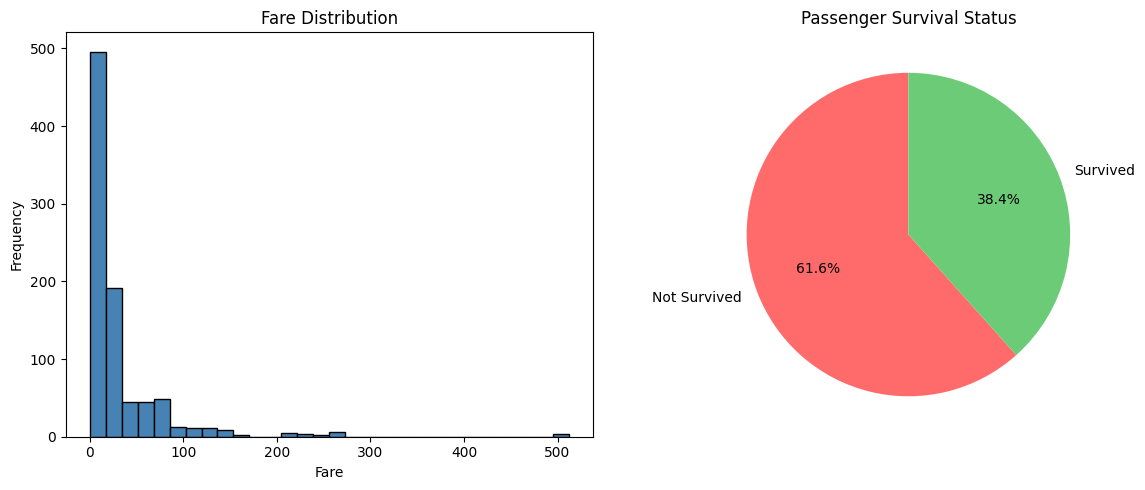

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(titanic["fare"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Fare Distribution")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Frequency")

survival_counts = titanic["survived"].value_counts()
axes[1].pie(
    survival_counts,
    labels=["Not Survived", "Survived"],
    autopct="%1.1f%%",
    colors=["#ff6b6b", "#6bcb77"],
    startangle=90
)
axes[1].set_title("Passenger Survival Status")

plt.tight_layout()
plt.show()

In [10]:
X = titanic.drop(columns=["survived"])
y = titanic["survived"]

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print("\nExperiment 2 complete!")

Training samples : 712
Testing  samples : 179

Experiment 2 complete!
